In [1]:
!pip install -q langchain langchain-text-splitters tiktoken pypdf fpdf2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.0/337.0 kB 17.3 MB/s eta 0:00:00


In [4]:
import os

os.makedirs("docs", exist_ok=True)

article_text = """Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters
to recommendation systems.

Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in photos or understanding the meaning of a sentence.

Natural Language Processing, or NLP, is the branch of AI that focuses specifically on human
language. NLP powers chatbots, translation tools, and search engines. A key building block of
modern NLP is the embedding, which converts words or sentences into numeric vectors that capture
meaning.

Retrieval-Augmented Generation, or RAG, is a technique that combines a search system with a
language model. Instead of relying only on what a language model memorized during training, RAG
first retrieves relevant, up-to-date information from a document collection, then passes that
information to the model so it can generate a more accurate, grounded answer.

Vector Databases store embeddings and allow fast similarity search across millions of documents.
They are a core infrastructure piece behind modern RAG systems, chatbots, and recommendation
engines used by companies around the world today.
"""

with open("docs/sample_article.txt", "w") as f:
    f.write(article_text)

print("Document created: docs/sample_article.txt")
print("Total characters:", len(article_text))
print("Total words:", len(article_text.split()))

Document created: docs/sample_article.txt
Total characters: 1786
Total words: 262


In [5]:
with open("docs/sample_article.txt", "r") as f:
    loaded_text = f.read()

print("Loaded document preview:\n")
print(loaded_text[:300], "...")

Loaded document preview:

Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from exp ...


In [6]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", size=12)

pdf.multi_cell(0, 10, article_text)

pdf.output("docs/sample_article.pdf")

print("PDF created: docs/sample_article.pdf")

PDF created: docs/sample_article.pdf


/tmp/ipykernel_3624/2812692687.py:5: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=12)


In [7]:
from pypdf import PdfReader

reader = PdfReader("docs/sample_article.pdf")

pdf_text = ""

for page in reader.pages:
    pdf_text += page.extract_text()

print("PDF loaded successfully!")
print("PDF text preview:\n")
print(pdf_text[:300], "...")

PDF loaded successfully!
PDF text preview:

Artificial Intelligence: An Overview
Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from expe ...


In [8]:
def fixed_size_chunking(text, chunk_size=300, overlap=50):
    chunks = []
    start = 0

    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap

    return chunks


fixed_chunks = fixed_size_chunking(
    loaded_text,
    chunk_size=300,
    overlap=50
)

print("Number of chunks:", len(fixed_chunks))
print("\n--- Chunk 1 ---\n", fixed_chunks[0])
print("\n--- Chunk 2 ---\n", fixed_chunks[1])

Number of chunks: 8

--- Chunk 1 ---
 Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from exp

--- Chunk 2 ---
 ng images, making decisions, and learning from experience.

Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own


In [9]:
from langchain_text_splitters import CharacterTextSplitter

char_splitter = CharacterTextSplitter(
    separator="\n\n",
    chunk_size=300,
    chunk_overlap=50
)

char_chunks = char_splitter.split_text(loaded_text)

print("Number of chunks:", len(char_chunks))

for i, chunk in enumerate(char_chunks):
    print(f"\n--- Chunk {i+1} ({len(chunk)} chars) ---")
    print(chunk)

Number of chunks: 7

--- Chunk 1 (36 chars) ---
Artificial Intelligence: An Overview

--- Chunk 2 (270 chars) ---
Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

--- Chunk 3 (318 chars) ---
Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters
to recommendation systems.

--- Chunk 4 (260 chars) ---
Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in photos or understanding the 

In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)

recursive_chunks = recursive_splitter.split_text(loaded_text)

print("Number of chunks:", len(recursive_chunks))

for i, chunk in enumerate(recursive_chunks):
    print(f"\n--- Chunk {i+1} ({len(chunk)} chars) ---")
    print(chunk)

Number of chunks: 9

--- Chunk 1 (36 chars) ---
Artificial Intelligence: An Overview

--- Chunk 2 (270 chars) ---
Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

--- Chunk 3 (291 chars) ---
Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters

--- Chunk 4 (26 chars) ---
to recommendation systems.

--- Chunk 5 (260 chars) ---
Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing faces in 

In [11]:
import re

sentences = re.split(r'(?<=[.!?])\s+', loaded_text.strip())

sentence_chunks = []

for sentence in sentences:
    sentence_chunks.append(sentence)

print("Number of sentence chunks:", len(sentence_chunks))

for i, chunk in enumerate(sentence_chunks):
    print(f"\n--- Sentence Chunk {i+1} ---")
    print(chunk)

Number of sentence chunks: 14

--- Sentence Chunk 1 ---
Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence.

--- Sentence Chunk 2 ---
These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

--- Sentence Chunk 3 ---
Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules.

--- Sentence Chunk 4 ---
Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own.

--- Sentence Chunk 5 ---
This approach powers everything from spam filters
to recommendation systems.

--- Sentence Chunk 6 ---
Deep Learning takes Machine Learning further by using neural networks with many layers.

--- Sentence Chunk 7 ---
These
layered networks can automatically discover complex patterns in la

In [12]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

tokens = encoding.encode(loaded_text)

chunk_size = 100
overlap = 20

token_chunks = []

for start in range(0, len(tokens), chunk_size - overlap):
    chunk_tokens = tokens[start:start + chunk_size]
    token_chunks.append(encoding.decode(chunk_tokens))

print("Number of token chunks:", len(token_chunks))

for i, chunk in enumerate(token_chunks):
    print(f"\n--- Token Chunk {i+1} ---")
    print(chunk)

Number of token chunks: 5

--- Token Chunk 1 ---
Artificial Intelligence: An Overview

Artificial Intelligence, or AI, is the field of computer science focused on building systems
that can perform tasks which normally require human intelligence. These tasks include
understanding language, recognizing images, making decisions, and learning from experience.

Machine Learning is a subset of AI where systems learn patterns from data instead of following
hardcoded rules. Instead of programming every decision by hand, we feed the system many examples,
and it learns the underlying pattern on its own.

--- Token Chunk 2 ---
 by hand, we feed the system many examples,
and it learns the underlying pattern on its own. This approach powers everything from spam filters
to recommendation systems.

Deep Learning takes Machine Learning further by using neural networks with many layers. These
layered networks can automatically discover complex patterns in large amounts of data, such as
recognizing face

In [13]:
import pandas as pd

strategies = {
    "Fixed-size (scratch)": fixed_chunks,
    "CharacterTextSplitter": char_chunks,
    "RecursiveCharacterTextSplitter": recursive_chunks,
    "Sentence-based": sentence_chunks,
    "Token-based": token_chunks
}

comparison = []

for name, chunks in strategies.items():
    avg_length = sum(len(c) for c in chunks) / len(chunks)
    comparison.append({
        "Strategy": name,
        "Number of Chunks": len(chunks),
        "Avg Chunk Length (chars)": round(avg_length, 1)
    })

df = pd.DataFrame(comparison)

df

,Strategy,Number of Chunks,Avg Chunk Length (chars)
0,Fixed-size (scratch),8,265.2
1,CharacterTextSplitter,7,253.3
2,RecursiveCharacterTextSplitter,9,196.8
3,Sentence-based,14,126.2
4,Token-based,5,427.2


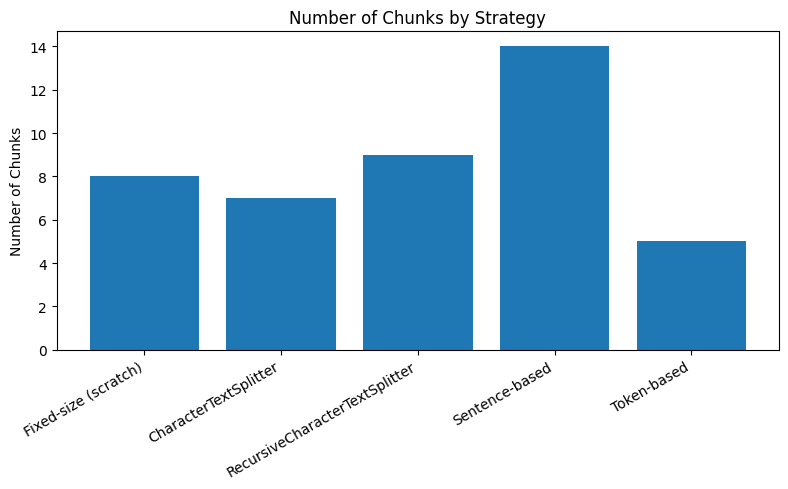

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(df["Strategy"], df["Number of Chunks"])

plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of Chunks")
plt.title("Number of Chunks by Strategy")

plt.tight_layout()
plt.show()